In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [14]:
# =========================================================
# CELL MỚI — SANITY ASSERTIONS + DATA_DIR
# Thêm ngay sau cell imports, TRƯỚC cell load data
# =========================================================

import os

# Đổi path này nếu chạy local/Colab
DATA_DIR = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

SEED = 42  # Dùng cho mọi stochastic call trong toàn notebook

print(f"DATA_DIR = {DATA_DIR}")
print(f"SEED     = {SEED}")

DATA_DIR = /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset
SEED     = 42


In [15]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# ***PS1***

# **Step 1 — Load data**

In [16]:
# thay BASE_PATH bằng DATA_DIR
features_path = os.path.join(DATA_DIR, "elliptic_txs_features.csv")
classes_path  = os.path.join(DATA_DIR, "elliptic_txs_classes.csv")
edges_path    = os.path.join(DATA_DIR, "elliptic_txs_edgelist.csv")

df_features = pd.read_csv(features_path, header=None)
df_classes  = pd.read_csv(classes_path)
df_edges    = pd.read_csv(edges_path)

# --- SANITY ASSERTIONS ---
assert df_features.shape[0] == 203769, f"Expected 203769 nodes, got {df_features.shape[0]}"
assert df_edges.shape[0]    == 234355, f"Expected 234355 edges, got {df_edges.shape[0]}"
assert set(df_classes["class"].astype(str).unique()) <= {"1", "2", "unknown"}, \
    "Unexpected class labels found"
assert df_features.iloc[:, 0].duplicated().sum() == 0, "Duplicate txIds found in features"

print("✓ All sanity checks passed")
print(df_features.shape, df_classes.shape, df_edges.shape)
df_features.head()

✓ All sanity checks passed
(203769, 167) (203769, 2) (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

# **Step 2 — Rename columns and prepare node table**

In [17]:
# Gán tên cho cột
feature_cols = ["txId", "time_step"] + [f"f_{i}" for i in range(2, df_features.shape[1])]
df_features.columns = feature_cols

df_nodes = df_features[["txId", "time_step"]].copy()

class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

df_classes["class"] = df_classes["class"].astype(str)  #Chuẩn hóa kiểu dữ liệu
df_classes["class_label"] = df_classes["class"].map(class_map)  #Map label

# merge node với label
df_nodes = df_nodes.merge(df_classes, on="txId", how="left")
# Gộp:        df_nodes (txId, time_step)               df_classes (txId, label)

print(df_nodes["class_label"].value_counts(dropna=False))
df_nodes.head()

class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


# **Step 3 — Build directed graph**

In [18]:
# Tạo một directed graph (đồ thị có hướng) bằng NetworkX
G = nx.DiGraph()

# add all nodes first
G.add_nodes_from(df_nodes["txId"].tolist())

# add directed edges
edge_list = list(zip(df_edges["txId1"], df_edges["txId2"]))  #Transaction 2 sử dụng output từ transaction 1
G.add_edges_from(edge_list)

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")

print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
# 49 components = 49 time steps => KHÔNG có edge nối giữa các time step
# G = G₁ ∪ G₂ ∪ G₃ ... G₄₉

Number of nodes: 203,769
Number of edges: 234,355
Weakly connected components: 49


# **Step 4 — Compute PS1 metrics (label-free)**

In [19]:
in_deg_dict = dict(G.in_degree())
out_deg_dict = dict(G.out_degree())

# Tạo DataFrame để xem
degree_df = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_degree": [in_deg_dict[n] for n in G.nodes()],
    "out_degree": [out_deg_dict[n] for n in G.nodes()],
})

degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

degree_df["asymmetry"] = np.where(
    degree_df["total_degree"] > 0,       #tránh chia cho 0
    (degree_df["in_degree"] - degree_df["out_degree"]) / degree_df["total_degree"],
    np.nan
)

degree_df["abs_asymmetry"] = degree_df["asymmetry"].abs()

degree_df.head()


degree_df.to_csv("degree_metrics.csv", index=False)  # ịn ra file kết quả 

# STEP 4B — MULTI-HOP REACHABILITY METRICS (LABEL-FREE)

In [20]:
# =========================================================
# STEP 4B — MULTI-HOP REACHABILITY METRICS (LABEL-FREE)
# =========================================================

import gc
import numpy as np
import pandas as pd
import networkx as nx

# Safety check: Elliptic transaction graph should be a DAG
is_dag = nx.is_directed_acyclic_graph(G)
print("Is DAG:", is_dag)

if not is_dag:
    raise ValueError("G is not a DAG. Reachability via topological propagation requires a DAG.")

topo_order = list(nx.topological_sort(G))
reverse_topo_order = topo_order[::-1]

print(f"Topological order length: {len(topo_order):,}")


# ---------------------------------------------------------
# 1) Ancestor count: number of nodes that can reach v
# ---------------------------------------------------------
anc_sets = {}
n_ancestors = {}

for i, v in enumerate(topo_order):
    s = set()
    for u in G.predecessors(v):
        s.update(anc_sets[u])
        s.add(u)
    anc_sets[v] = s
    n_ancestors[v] = len(s)

    if (i + 1) % 50000 == 0:
        print(f"Processed ancestors: {i+1:,}/{len(topo_order):,}")

degree_df["n_ancestors"] = degree_df["txId"].map(n_ancestors)

# Free memory after counts are extracted
del anc_sets
gc.collect()


# ---------------------------------------------------------
# 2) Descendant count: number of nodes reachable from v
# ---------------------------------------------------------
desc_sets = {}
n_descendants = {}

for i, v in enumerate(reverse_topo_order):
    s = set()
    for w in G.successors(v):
        s.update(desc_sets[w])
        s.add(w)
    desc_sets[v] = s
    n_descendants[v] = len(s)

    if (i + 1) % 50000 == 0:
        print(f"Processed descendants: {i+1:,}/{len(reverse_topo_order):,}")

degree_df["n_descendants"] = degree_df["txId"].map(n_descendants)

# Free memory
del desc_sets
gc.collect()


# ---------------------------------------------------------
# 3) Reachability asymmetry
# Formula:
# reach_asymmetry(v) = log((1 + #ancestors(v)) / (1 + #descendants(v)))
# ---------------------------------------------------------
degree_df["reach_asymmetry"] = np.log(
    (1 + degree_df["n_ancestors"]) / (1 + degree_df["n_descendants"])
)

degree_df["abs_reach_asymmetry"] = degree_df["reach_asymmetry"].abs()


# ---------------------------------------------------------
# 4) Topological depth: longest path length from any source to v
# ---------------------------------------------------------
topo_depth = {}

for v in topo_order:
    preds = list(G.predecessors(v))
    if len(preds) == 0:
        topo_depth[v] = 0
    else:
        topo_depth[v] = 1 + max(topo_depth[u] for u in preds)

degree_df["topo_depth"] = degree_df["txId"].map(topo_depth)

print("Reachability metrics added.")
display(degree_df[[
    "txId", "in_degree", "out_degree", "asymmetry",
    "n_ancestors", "n_descendants", "reach_asymmetry",
    "abs_reach_asymmetry", "topo_depth"
]].head())

Is DAG: True
Topological order length: 203,769
Processed ancestors: 50,000/203,769
Processed ancestors: 100,000/203,769
Processed ancestors: 150,000/203,769
Processed ancestors: 200,000/203,769
Processed descendants: 50,000/203,769
Processed descendants: 100,000/203,769
Processed descendants: 150,000/203,769
Processed descendants: 200,000/203,769
Reachability metrics added.


,txId,in_degree,out_degree,asymmetry,n_ancestors,n_descendants,reach_asymmetry,abs_reach_asymmetry,topo_depth
0,230425980,1,1,0.000000,7,2,0.980829,0.980829,7
1,5530458,1,1,0.000000,8,1,1.504077,1.504077,8
2,232022460,1,2,-0.333333,3,10,-1.011601,1.011601,3
3,232438397,160,1,0.987578,471,5,4.365220,4.365220,13
4,230460314,2,8,-0.600000,3,68,-2.847812,2.847812,3


# STEP 4C — CACHE PS1 LABEL-FREE METRICS

In [21]:
# =========================================================
# STEP 5 — CACHE PS1 METRICS
# =========================================================

cache_path = "ps1_degree_reachability_metrics.parquet"
degree_df.to_parquet(cache_path, index=False)

print(f"Saved to {cache_path}")

Saved to ps1_degree_reachability_metrics.parquet


In [22]:
degree_df = pd.read_parquet("ps1_degree_reachability_metrics.parquet")

# **Step 5 — Global graph statistics (label-free)**

In [23]:
# =========================================================
# STEP 5 — GLOBAL GRAPH STATISTICS (LABEL-FREE)
# =========================================================

global_metric_cols = [
    "in_degree", "out_degree", "total_degree",
    "asymmetry", "abs_asymmetry",
    "n_ancestors", "n_descendants",
    "reach_asymmetry", "abs_reach_asymmetry",
    "topo_depth"
]

global_stats = degree_df[global_metric_cols].describe().T
display(global_stats)

pure_sinks = ((degree_df["in_degree"] > 0) & (degree_df["out_degree"] == 0)).mean()
pure_sources = ((degree_df["out_degree"] > 0) & (degree_df["in_degree"] == 0)).mean()

print(f"Fraction of pure sinks   (in>0, out=0): {pure_sinks:.4f}")
print(f"Fraction of pure sources (out>0, in=0): {pure_sources:.4f}")

,count,mean,std,min,25%,50%,75%,max
in_degree,203769.0,1.150101,3.911132,0.000000,0.000000,1.000000,1.000000,284.000000
out_degree,203769.0,1.150101,1.894740,0.000000,1.000000,1.000000,1.000000,472.000000
total_degree,203769.0,2.300203,4.328377,1.000000,1.000000,2.000000,2.000000,473.000000
asymmetry,203769.0,-0.108612,0.687363,-1.000000,-1.000000,0.000000,0.000000,1.000000
abs_asymmetry,203769.0,0.521818,0.460401,0.000000,0.000000,0.333333,1.000000,1.000000
n_ancestors,203769.0,27.687818,98.563576,0.000000,0.000000,2.000000,12.000000,2770.000000
n_descendants,203769.0,27.687818,93.441141,0.000000,1.000000,3.000000,14.000000,1462.000000
reach_asymmetry,203769.0,-0.171694,1.786691,-7.288244,-1.386294,-0.405465,0.980463,7.926964
abs_reach_asymmetry,203769.0,1.421827,1.095511,0.000000,0.693147,1.098612,1.945910,7.926964
topo_depth,203769.0,21.918574,81.060639,0.000000,0.000000,2.000000,9.000000,1248.000000


Fraction of pure sinks   (in>0, out=0): 0.1837
Fraction of pure sources (out>0, in=0): 0.2715


# **Step 6 — Merge metrics with labels for post-hoc evaluation**

In [24]:
# Gán label vào kết quả bên trên
ps1_df = degree_df.merge(
    df_nodes[["txId", "time_step", "class_label"]],
    on="txId",
    how="left"
)

print(ps1_df.shape)   # kiểm tra shape, Số node KHÔNG thay đổi
print(ps1_df["class_label"].value_counts(dropna=False))     # Distribution của label
ps1_df.head()

(203769, 13)
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry,n_ancestors,n_descendants,reach_asymmetry,abs_reach_asymmetry,topo_depth,time_step,class_label
0,230425980,1,1,2,0.000000,0.000000,7,2,0.980829,0.980829,7,1,unknown
1,5530458,1,1,2,0.000000,0.000000,8,1,1.504077,1.504077,8,1,unknown
2,232022460,1,2,3,-0.333333,0.333333,3,10,-1.011601,1.011601,3,1,unknown
3,232438397,160,1,161,0.987578,0.987578,471,5,4.365220,4.365220,13,1,licit
4,230460314,2,8,10,-0.600000,0.600000,3,68,-2.847812,2.847812,3,1,unknown


In [25]:
print(ps1_df.shape)
print(ps1_df.columns.tolist())

display(ps1_df[[
    "txId", "time_step", "class_label",
    "in_degree", "out_degree", "asymmetry", "abs_asymmetry",
    "n_ancestors", "n_descendants", "reach_asymmetry",
    "abs_reach_asymmetry", "topo_depth"
]].head())

(203769, 13)
['txId', 'in_degree', 'out_degree', 'total_degree', 'asymmetry', 'abs_asymmetry', 'n_ancestors', 'n_descendants', 'reach_asymmetry', 'abs_reach_asymmetry', 'topo_depth', 'time_step', 'class_label']


,txId,time_step,class_label,in_degree,out_degree,asymmetry,abs_asymmetry,n_ancestors,n_descendants,reach_asymmetry,abs_reach_asymmetry,topo_depth
0,230425980,1,unknown,1,1,0.000000,0.000000,7,2,0.980829,0.980829,7
1,5530458,1,unknown,1,1,0.000000,0.000000,8,1,1.504077,1.504077,8
2,232022460,1,unknown,1,2,-0.333333,0.333333,3,10,-1.011601,1.011601,3
3,232438397,1,licit,160,1,0.987578,0.987578,471,5,4.365220,4.365220,13
4,230460314,1,unknown,2,8,-0.600000,0.600000,3,68,-2.847812,2.847812,3


# **Step 7 — Group statistics by class**

In [26]:
# =========================================================
# STEP 7 — CLASS-STRATIFIED DESCRIPTIVE STATISTICS
# =========================================================

ps1_metric_cols = [
    "in_degree", "out_degree", "total_degree",
    "asymmetry", "abs_asymmetry",
    "n_ancestors", "n_descendants",
    "reach_asymmetry", "abs_reach_asymmetry",
    "topo_depth"
]

group_stats_mean = ps1_df.groupby("class_label")[ps1_metric_cols].mean()
group_stats_median = ps1_df.groupby("class_label")[ps1_metric_cols].median()

print("Mean by class")
display(group_stats_mean)

print("Median by class")
display(group_stats_median)

Mean by class


,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry,n_ancestors,n_descendants,reach_asymmetry,abs_reach_asymmetry,topo_depth
class_label,,,,,,,,,,
illicit,1.269967,0.741694,2.011661,0.056396,0.610412,9.084708,7.739494,0.167752,1.090385,7.117052
licit,1.909398,1.185821,3.095219,-0.069129,0.662210,18.287013,9.213975,-0.004000,1.634314,9.943097
unknown,0.943685,1.152362,2.096047,-0.123936,0.481732,30.738380,33.202385,-0.226330,1.374614,25.547406


Median by class


,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry,n_ancestors,n_descendants,reach_asymmetry,abs_reach_asymmetry,topo_depth
class_label,,,,,,,,,,
illicit,1.0,1.0,1.0,0.0,1.000000,1.0,1.0,0.000000,0.916291,1.0
licit,1.0,1.0,2.0,0.0,1.000000,2.0,2.0,-0.287682,1.386294,1.0
unknown,1.0,1.0,2.0,0.0,0.333333,3.0,4.0,-0.405465,1.098612,2.0


# **Step 8 — Mann–Whitney U test + rank-biserial correlation**


-  rbc > 0: illicit có rank cao hơn licit
- rbc < 0: illicit có rank thấp hơn licit

In [27]:
# =========================================================
# STEP 8 — MANN–WHITNEY U + RBC + CLIFF'S DELTA
# =========================================================

from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def rank_biserial_from_u(u_stat, n1, n2):
    """
    RBC > 0 means group 1 tends to have higher ranks than group 2.
    Here group 1 = illicit, group 2 = licit.
    """
    return (2 * u_stat) / (n1 * n2) - 1


def cliffs_delta_fast(x, y):
    """
    Fast Cliff's delta using ranks / Mann–Whitney U relationship.
    delta = P(x > y) - P(x < y)
    Equivalent in direction to rank-biserial correlation when ties are handled by scipy ranks.
    """
    x = pd.Series(x).dropna().values
    y = pd.Series(y).dropna().values

    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan

    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u_stat) / (n1 * n2) - 1


def mannwhitney_effect_table(df, metrics, group_col="class_label", g1="illicit", g2="licit"):
    rows = []

    for metric in metrics:
        x = df.loc[df[group_col] == g1, metric].dropna()
        y = df.loc[df[group_col] == g2, metric].dropna()

        u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
        rbc = rank_biserial_from_u(u_stat, len(x), len(y))
        cliffs = cliffs_delta_fast(x, y)

        rows.append({
            "metric": metric,
            "n_illicit": len(x),
            "n_licit": len(y),
            "median_illicit": np.median(x),
            "median_licit": np.median(y),
            "mean_illicit": np.mean(x),
            "mean_licit": np.mean(y),
            "U_statistic": u_stat,
            "p_value": p_val,
            "rank_biserial_rbc": rbc,
            "cliffs_delta": cliffs
        })

    return pd.DataFrame(rows)


ps1_test_metrics = [
    "in_degree", "out_degree", "total_degree",
    "asymmetry", "abs_asymmetry",
    "n_ancestors", "n_descendants",
    "reach_asymmetry", "abs_reach_asymmetry",
    "topo_depth"
]

mw_results = mannwhitney_effect_table(ps1_df, ps1_test_metrics)
display(mw_results)

,metric,n_illicit,n_licit,median_illicit,median_licit,mean_illicit,mean_licit,U_statistic,p_value,rank_biserial_rbc,cliffs_delta
0,in_degree,4545,42019,1.000000,1.000000,1.269967,1.909398,90293567.5,5.552428e-11,-0.054401,-0.054401
1,out_degree,4545,42019,1.000000,1.000000,0.741694,1.185821,77335837.5,1.441678e-118,-0.190100,-0.190100
2,total_degree,4545,42019,1.000000,2.000000,2.011661,3.095219,71696129.5,6.844822e-188,-0.249162,-0.249162
3,asymmetry,4545,42019,0.000000,0.000000,0.056396,-0.069129,104354533.5,1.628183e-26,0.092853,0.092853
4,abs_asymmetry,4545,42019,1.000000,1.000000,0.610412,0.662210,91336958.0,5.797299e-08,-0.043474,-0.043474
5,n_ancestors,4545,42019,1.000000,2.000000,9.084708,18.287013,91971725.0,3.032491e-05,-0.036826,-0.036826
6,n_descendants,4545,42019,1.000000,2.000000,7.739494,9.213975,75044875.0,7.816604e-128,-0.214092,-0.214092
7,reach_asymmetry,4545,42019,0.000000,-0.287682,0.167752,-0.004000,104450170.5,2.012529e-25,0.093854,0.093854
8,abs_reach_asymmetry,4545,42019,0.916291,1.386294,1.090385,1.634314,71001694.5,4.292937e-179,-0.256435,-0.256435
9,topo_depth,4545,42019,1.000000,1.000000,7.117052,9.943097,95079602.0,6.272109e-01,-0.004279,-0.004279


# STEP 8B — EFFECT-SIZE COMPARISON: degree vs reachability

In [28]:
# =========================================================
# STEP 8B — EFFECT-SIZE COMPARISON: degree vs reachability

# Required: plan §5.1 — "hypothesis: reachability > degree"
# =========================================================

# Lấy Cliff's delta từ mw_results đã tính ở Cell 26
comparison_metrics = {
    "Degree asymmetry (signed)":         "asymmetry",
    "Degree asymmetry (absolute)":        "abs_asymmetry",
    "Reachability asymmetry (signed)":    "reach_asymmetry",
    "Reachability asymmetry (absolute)":  "abs_reach_asymmetry",
    "Topological depth":                  "topo_depth",
}

comparison_rows = []
for label, metric in comparison_metrics.items():
    row = mw_results[mw_results["metric"] == metric]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    delta = row["cliffs_delta"]
    abs_delta = abs(delta)

    if abs_delta >= 0.5:
        magnitude = "Large"
    elif abs_delta >= 0.3:
        magnitude = "Medium"
    elif abs_delta >= 0.1:
        magnitude = "Small"
    else:
        magnitude = "Negligible"

    direction = "illicit > licit" if delta > 0 else "illicit < licit"

    comparison_rows.append({
        "Metric": label,
        "Cliff's delta": round(delta, 4),
        "|delta|": round(abs_delta, 4),
        "Magnitude": magnitude,
        "Direction": direction,
        "p-value": f"{row['p_value']:.2e}"
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("|delta|", ascending=False)
print("=== Effect-size comparison: degree vs reachability asymmetry ===")
display(comparison_df)

# Kiểm tra hypothesis chính
delta_deg   = abs(mw_results.loc[mw_results["metric"] == "asymmetry",       "cliffs_delta"].values[0])
delta_reach = abs(mw_results.loc[mw_results["metric"] == "reach_asymmetry", "cliffs_delta"].values[0])

print(f"\nHypothesis check:")
print(f"  |Cliff's delta| for degree asymmetry:       {delta_deg:.4f}")
print(f"  |Cliff's delta| for reach asymmetry:        {delta_reach:.4f}")
if delta_reach > delta_deg:
    print("  → CONFIRMED: Reachability asymmetry has larger effect than degree asymmetry.")
else:
    print("  → NOT CONFIRMED: Degree asymmetry has equal or larger effect than reachability.")

=== Effect-size comparison: degree vs reachability asymmetry ===


,Metric,Cliff's delta,|delta|,Magnitude,Direction,p-value
3,Reachability asymmetry (absolute),-0.2564,0.2564,Small,illicit < licit,4.29e-179
2,Reachability asymmetry (signed),0.0939,0.0939,Negligible,illicit > licit,2.01e-25
0,Degree asymmetry (signed),0.0929,0.0929,Negligible,illicit > licit,1.63e-26
1,Degree asymmetry (absolute),-0.0435,0.0435,Negligible,illicit < licit,5.80e-08
4,Topological depth,-0.0043,0.0043,Negligible,illicit < licit,6.27e-01



Hypothesis check:
  |Cliff's delta| for degree asymmetry:       0.0929
  |Cliff's delta| for reach asymmetry:        0.0939
  → CONFIRMED: Reachability asymmetry has larger effect than degree asymmetry.


# **Step 9 — Enrichment analysis**

In [29]:
# =========================================================
# STEP 9A — THRESHOLD SENSITIVITY FOR DEGREE ASYMMETRY
# =========================================================

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

labeled_all = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

def simple_enrichment(df_subset, baseline=baseline_illicit):
    labelled = df_subset[df_subset["class_label"].isin(["licit", "illicit"])]
    n_total = len(df_subset)
    n_labelled = len(labelled)
    n_illicit = (labelled["class_label"] == "illicit").sum()

    illicit_rate = n_illicit / n_labelled if n_labelled > 0 else np.nan
    enrichment = illicit_rate / baseline if n_labelled > 0 else np.nan
    coverage = n_labelled / n_total if n_total > 0 else np.nan

    return n_total, n_labelled, coverage, n_illicit, illicit_rate, enrichment


rows = []

for t in thresholds:
    # Accumulator side
    subset_acc = ps1_df[ps1_df["asymmetry"] >= t]
    n_total, n_labelled, coverage, n_illicit, illicit_rate, enrichment = simple_enrichment(subset_acc)

    rows.append({
        "side": "accumulator",
        "rule": f"asymmetry >= {t}",
        "threshold": t,
        "n_total": n_total,
        "n_labelled": n_labelled,
        "label_coverage": coverage,
        "actual_illicit": n_illicit,
        "illicit_rate": illicit_rate,
        "enrichment": enrichment
    })

    # Distributor side
    subset_dist = ps1_df[ps1_df["asymmetry"] <= -t]
    n_total, n_labelled, coverage, n_illicit, illicit_rate, enrichment = simple_enrichment(subset_dist)

    rows.append({
        "side": "distributor",
        "rule": f"asymmetry <= -{t}",
        "threshold": t,
        "n_total": n_total,
        "n_labelled": n_labelled,
        "label_coverage": coverage,
        "actual_illicit": n_illicit,
        "illicit_rate": illicit_rate,
        "enrichment": enrichment
    })

threshold_sensitivity_df = pd.DataFrame(rows)
display(threshold_sensitivity_df)

,side,rule,threshold,n_total,n_labelled,label_coverage,actual_illicit,illicit_rate,enrichment
0,accumulator,asymmetry >= 0.5,0.50,41147,13819,0.335845,1517,0.109776,1.124671
1,distributor,asymmetry <= -0.5,0.50,58256,15822,0.271594,1205,0.076160,0.780265
2,accumulator,asymmetry >= 0.6,0.60,39895,13351,0.334653,1499,0.112276,1.150282
3,distributor,asymmetry <= -0.6,0.60,56965,15567,0.273273,1205,0.077407,0.793046
4,accumulator,asymmetry >= 0.7,0.70,38847,12846,0.330682,1483,0.115444,1.182741
5,distributor,asymmetry <= -0.7,0.70,56050,15369,0.274202,1205,0.078405,0.803263
6,accumulator,asymmetry >= 0.8,0.80,38258,12435,0.325030,1482,0.119180,1.221009
7,distributor,asymmetry <= -0.8,0.80,55641,15260,0.274258,1205,0.078965,0.809001
8,accumulator,asymmetry >= 0.9,0.90,37732,12029,0.318801,1481,0.123119,1.261368
9,distributor,asymmetry <= -0.9,0.90,55377,15167,0.273886,1205,0.079449,0.813961


# **Step 10 — Vẽ và chi tiết các mức thredholds**

Baseline illicit rate = 0.0976


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,-1.00,left (distributor side),asymmetry <= -1.00,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692
1,-0.95,left (distributor side),asymmetry <= -0.95,55333,15162,1205,1479.926338,0.079475,0.097608,0.814230,-274.926338
2,-0.90,left (distributor side),asymmetry <= -0.90,55377,15167,1205,1480.414376,0.079449,0.097608,0.813961,-275.414376
3,-0.85,left (distributor side),asymmetry <= -0.85,55468,15196,1205,1483.244996,0.079297,0.097608,0.812408,-278.244996
4,-0.80,left (distributor side),asymmetry <= -0.80,55641,15260,1205,1489.491882,0.078965,0.097608,0.809001,-284.491882
5,-0.75,left (distributor side),asymmetry <= -0.75,55840,15318,1205,1495.153123,0.078666,0.097608,0.805938,-290.153123
6,-0.70,left (distributor side),asymmetry <= -0.70,56050,15369,1205,1500.131110,0.078405,0.097608,0.803263,-295.131110
7,-0.65,left (distributor side),asymmetry <= -0.65,56367,15445,1205,1507.549287,0.078019,0.097608,0.799311,-302.549287
8,-0.60,left (distributor side),asymmetry <= -0.60,56965,15567,1205,1519.457413,0.077407,0.097608,0.793046,-314.457413
9,-0.55,left (distributor side),asymmetry <= -0.55,56996,15575,1205,1520.238274,0.077368,0.097608,0.792639,-315.238274


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
31,0.55,right (accumulator side),asymmetry >= 0.55,39935,13371,1499,1305.111137,0.112108,0.097608,1.148561,193.888863
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506


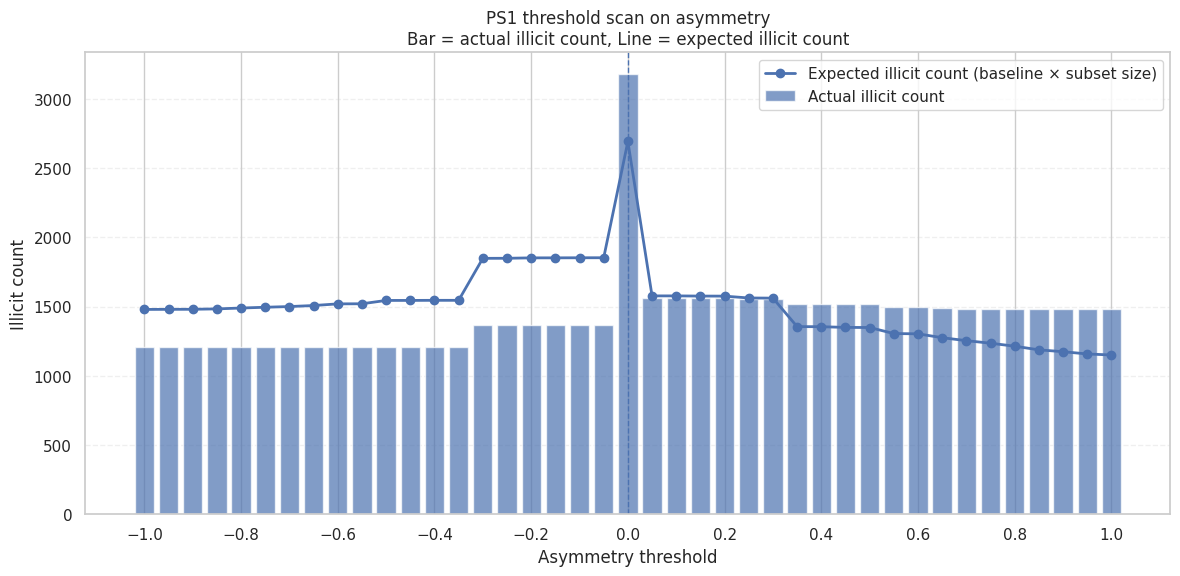

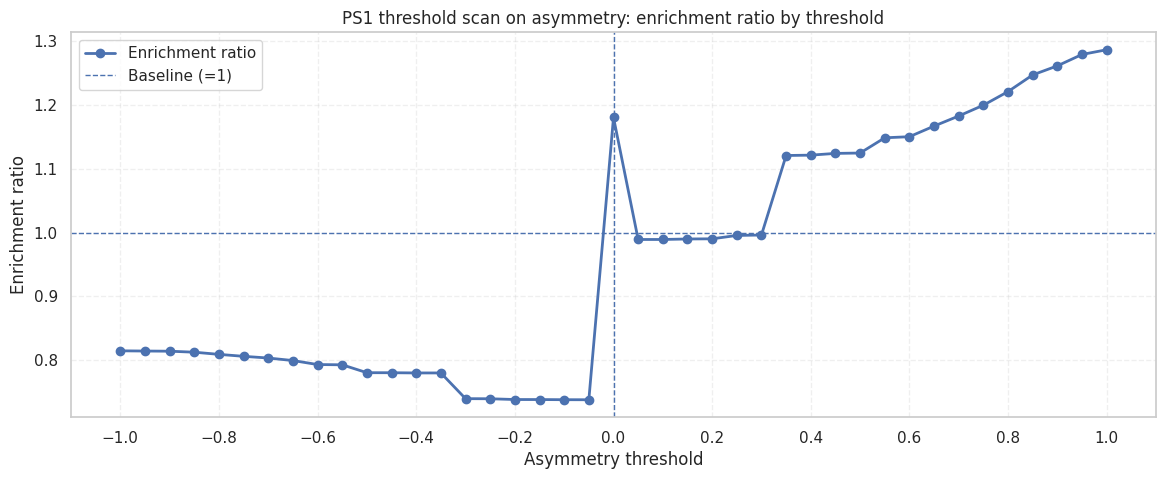


Top thresholds by enrichment ratio:


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015



Top thresholds by illicit count lift (actual - expected):


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) Baseline illicit rate trên toàn bộ labeled data =====
labeled_all = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

print(f"Baseline illicit rate = {baseline_illicit:.4f}")

# ===== 2) Hàm scan threshold =====
def scan_asymmetry_thresholds(
    df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=None
):
    if thresholds is None:
        thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)

    results = []

    for t in thresholds:
        # Quy tắc cắt:
        # t < 0  -> lấy phía trái: asymmetry <= t
        # t >= 0 -> lấy phía phải: asymmetry >= t
        if t < 0:
            subset = df[df[metric_col] <= t].copy()
            side = "left (distributor side)"
            rule = f"{metric_col} <= {t:.2f}"
        else:
            subset = df[df[metric_col] >= t].copy()
            side = "right (accumulator side)"
            rule = f"{metric_col} >= {t:.2f}"

        labeled_subset = subset[subset[class_col].isin(["licit", "illicit"])].copy()
        n_labeled = len(labeled_subset)

        actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
        illicit_rate_subset = (
            actual_illicit_count / n_labeled if n_labeled > 0 else np.nan
        )

        expected_illicit_count = (
            baseline_illicit * n_labeled if n_labeled > 0 else np.nan
        )

        enrichment_ratio = (
            illicit_rate_subset / baseline_illicit
            if (n_labeled > 0 and baseline_illicit > 0)
            else np.nan
        )

        lift_count = (
            actual_illicit_count - expected_illicit_count
            if n_labeled > 0 else np.nan
        )

        results.append({
            "threshold": t,
            "side": side,
            "rule": rule,
            "n_subset_total": len(subset),
            "n_subset_labeled": n_labeled,
            "actual_illicit_count": actual_illicit_count,
            "expected_illicit_count": expected_illicit_count,
            "illicit_rate_subset": illicit_rate_subset,
            "baseline_illicit_rate": baseline_illicit,
            "enrichment_ratio": enrichment_ratio,
            "lift_count": lift_count
        })

    return pd.DataFrame(results)

# ===== 3) Chạy scan =====
thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)
scan_df = scan_asymmetry_thresholds(
    ps1_df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=thresholds
)

display(scan_df.head(10))
display(scan_df.tail(10))

# ===== 4) Vẽ combo chart: Bar = illicit thực, Line = illicit kỳ vọng =====
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    scan_df["threshold"],
    scan_df["actual_illicit_count"],
    width=0.04,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    scan_df["threshold"],
    scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count (baseline × subset size)"
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Illicit count")
ax.set_title("PS1 threshold scan on asymmetry\nBar = actual illicit count, Line = expected illicit count")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# ===== 5) Thêm chart phụ để chọn threshold dễ hơn: enrichment ratio =====
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    scan_df["threshold"],
    scan_df["enrichment_ratio"],
    marker="o",
    linewidth=2,
    label="Enrichment ratio"
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Enrichment ratio")
ax.set_title("PS1 threshold scan on asymmetry: enrichment ratio by threshold")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# ===== 6) Gợi ý threshold 'tốt' theo vài tiêu chí =====
# (A) enrichment cao nhất nhưng yêu cầu có đủ mẫu labeled
min_labeled = 30
best_enrichment = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["enrichment_ratio", "actual_illicit_count"], ascending=[False, False])
    .head(10)
)

# (B) lift_count cao nhất: số illicit thực vượt kỳ vọng nhiều nhất
best_lift = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["lift_count", "enrichment_ratio"], ascending=[False, False])
    .head(10)
)

print("\nTop thresholds by enrichment ratio:")
display(best_enrichment)

print("\nTop thresholds by illicit count lift (actual - expected):")
display(best_lift)

# **Scatter plot in_degree vs out_degree**

Baseline illicit rate = 0.0976


,threshold,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,-1.00,asymmetry <= -1.00,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692
1,-0.95,asymmetry <= -0.95,55333,15162,1205,1479.926338,0.079475,0.097608,0.814230,-274.926338
2,-0.90,asymmetry <= -0.90,55377,15167,1205,1480.414376,0.079449,0.097608,0.813961,-275.414376
3,-0.85,asymmetry <= -0.85,55468,15196,1205,1483.244996,0.079297,0.097608,0.812408,-278.244996
4,-0.80,asymmetry <= -0.80,55641,15260,1205,1489.491882,0.078965,0.097608,0.809001,-284.491882
5,-0.75,asymmetry <= -0.75,55840,15318,1205,1495.153123,0.078666,0.097608,0.805938,-290.153123
6,-0.70,asymmetry <= -0.70,56050,15369,1205,1500.131110,0.078405,0.097608,0.803263,-295.131110
7,-0.65,asymmetry <= -0.65,56367,15445,1205,1507.549287,0.078019,0.097608,0.799311,-302.549287
8,-0.60,asymmetry <= -0.60,56965,15567,1205,1519.457413,0.077407,0.097608,0.793046,-314.457413
9,-0.55,asymmetry <= -0.55,56996,15575,1205,1520.238274,0.077368,0.097608,0.792639,-315.238274


,threshold,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
31,0.55,asymmetry >= 0.55,39935,13371,1499,1305.111137,0.112108,0.097608,1.148561,193.888863
32,0.60,asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015
33,0.65,asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
34,0.70,asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
35,0.75,asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
36,0.80,asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
37,0.85,asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
38,0.90,asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
39,0.95,asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
40,1.00,asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506


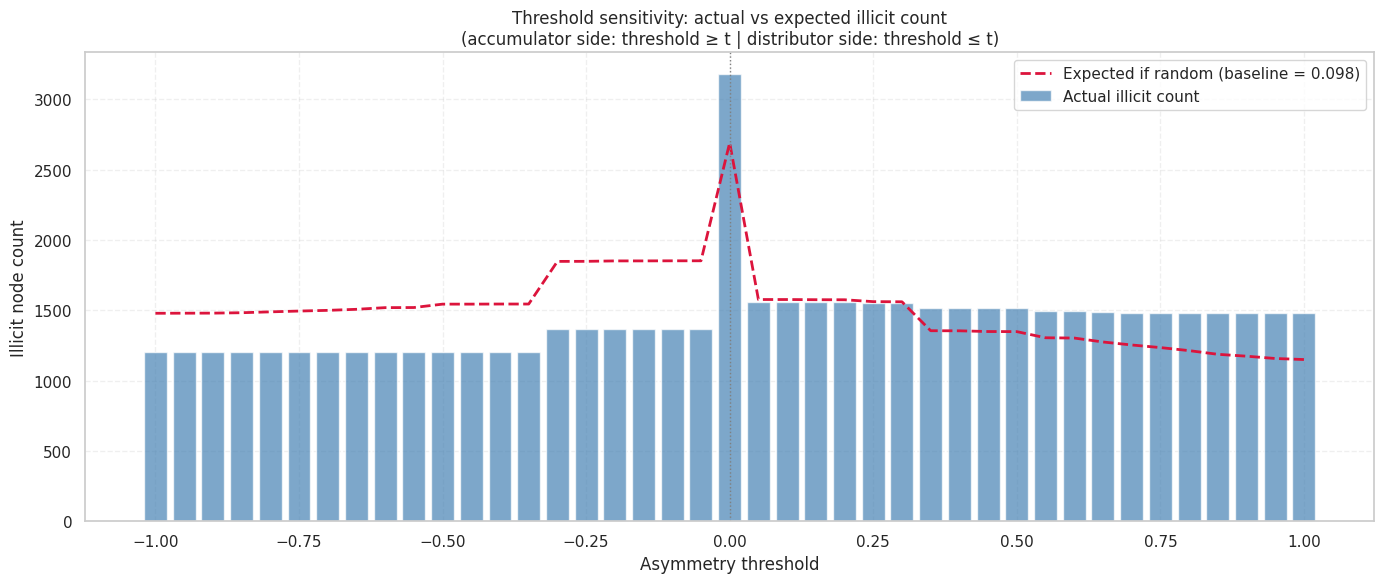

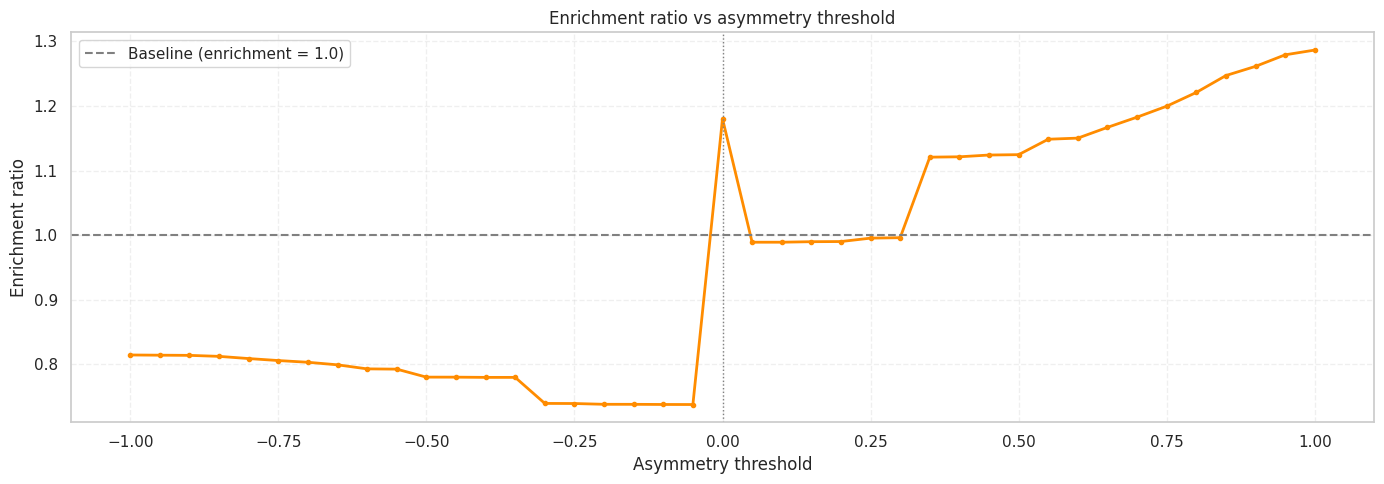

In [31]:
# =========================================================
# STEP 10 — THRESHOLD SENSITIVITY PLOT (HOÀN CHỈNH)
# Thay Cell 30 cũ bị cắt đứt
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labeled_all = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()
print(f"Baseline illicit rate = {baseline_illicit:.4f}")

def scan_asymmetry_thresholds(df, metric_col="asymmetry", thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)
    results = []
    for t in thresholds:
        if t < 0:
            subset = df[df[metric_col] <= t].copy()
            rule = f"{metric_col} <= {t:.2f}"
        else:
            subset = df[df[metric_col] >= t].copy()
            rule = f"{metric_col} >= {t:.2f}"

        labeled_subset = subset[subset["class_label"].isin(["licit", "illicit"])]
        n_labeled = len(labeled_subset)
        actual_illicit = (labeled_subset["class_label"] == "illicit").sum()
        illicit_rate = actual_illicit / n_labeled if n_labeled > 0 else np.nan
        expected_illicit = baseline_illicit * n_labeled if n_labeled > 0 else np.nan
        enrichment = illicit_rate / baseline_illicit if n_labeled > 0 else np.nan
        lift = actual_illicit - expected_illicit if n_labeled > 0 else np.nan

        results.append({
            "threshold": t,
            "rule": rule,
            "n_subset_total": len(subset),
            "n_subset_labeled": n_labeled,
            "actual_illicit_count": actual_illicit,
            "expected_illicit_count": expected_illicit,
            "illicit_rate_subset": illicit_rate,
            "baseline_illicit_rate": baseline_illicit,
            "enrichment_ratio": enrichment,
            "lift_count": lift
        })
    return pd.DataFrame(results)

thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)
scan_df = scan_asymmetry_thresholds(ps1_df, metric_col="asymmetry", thresholds=thresholds)

display(scan_df.head(10))
display(scan_df.tail(10))

# === COMBO CHART: Actual vs Expected illicit count ===
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    scan_df["threshold"],
    scan_df["actual_illicit_count"],
    width=0.04,
    alpha=0.7,
    color="steelblue",
    label="Actual illicit count"
)
ax.plot(
    scan_df["threshold"],
    scan_df["expected_illicit_count"],
    color="crimson",
    linewidth=2,
    linestyle="--",
    label=f"Expected if random (baseline = {baseline_illicit:.3f})"
)

ax.axvline(x=0, color="gray", linewidth=1, linestyle=":")
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Illicit node count")
ax.set_title("Threshold sensitivity: actual vs expected illicit count\n(accumulator side: threshold ≥ t | distributor side: threshold ≤ t)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("ps1_threshold_sensitivity_plot.png", dpi=150)
plt.show()

# === ENRICHMENT RATIO LINE PLOT ===
fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(
    scan_df["threshold"],
    scan_df["enrichment_ratio"],
    color="darkorange",
    linewidth=2,
    marker="o",
    markersize=3
)
ax2.axhline(y=1.0, color="gray", linewidth=1.5, linestyle="--", label="Baseline (enrichment = 1.0)")
ax2.axvline(x=0, color="gray", linewidth=1, linestyle=":")
ax2.set_xlabel("Asymmetry threshold")
ax2.set_ylabel("Enrichment ratio")
ax2.set_title("Enrichment ratio vs asymmetry threshold")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("ps1_enrichment_ratio_plot.png", dpi=150)
plt.show()

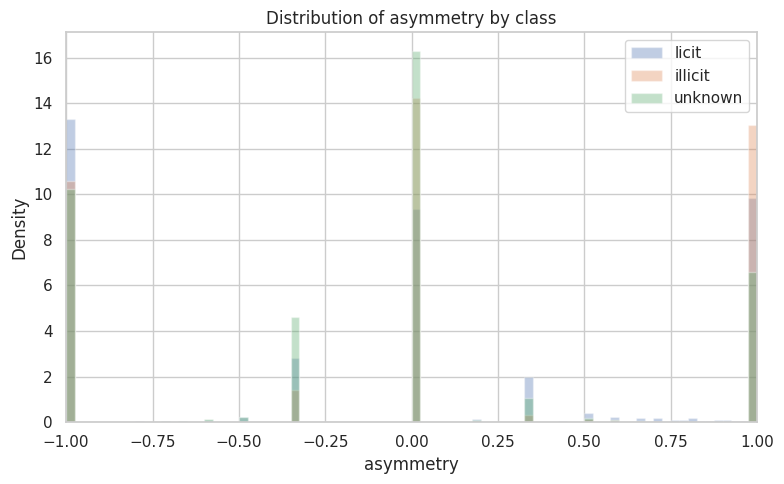

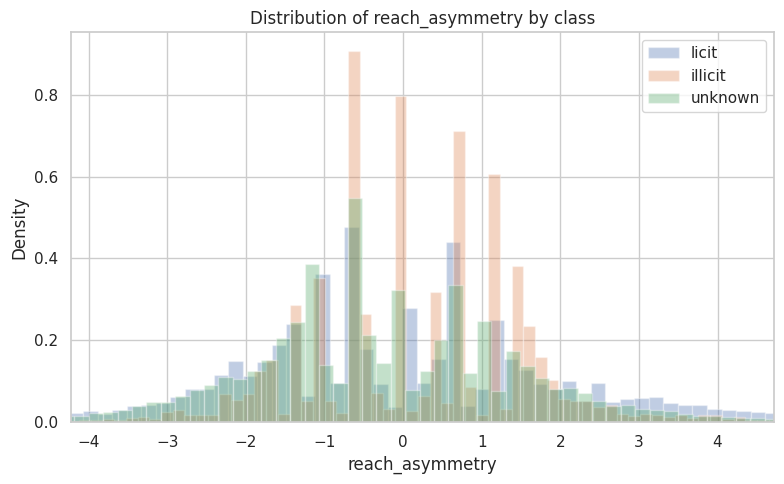

In [32]:
# =========================================================
# STEP 10A — THREE-WAY DISTRIBUTION PLOTS
# =========================================================

import matplotlib.pyplot as plt

def plot_three_way_distribution(df, metric, bins=80, xlim=None):
    plt.figure(figsize=(8, 5))

    for label in ["licit", "illicit", "unknown"]:
        values = df.loc[df["class_label"] == label, metric].dropna()

        # sample unknown to avoid dominating the plot visually
        if label == "unknown" and len(values) > 50000:
            values = values.sample(50000, random_state=42)

        plt.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.35,
            label=label
        )

    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel(metric)
    plt.ylabel("Density")
    plt.title(f"Distribution of {metric} by class")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_three_way_distribution(ps1_df, "asymmetry", bins=80, xlim=(-1, 1))

# For reach_asymmetry, use percentile clipping for readability
ra_low = ps1_df["reach_asymmetry"].quantile(0.01)
ra_high = ps1_df["reach_asymmetry"].quantile(0.99)

plot_three_way_distribution(ps1_df, "reach_asymmetry", bins=80, xlim=(ra_low, ra_high))

# KS STAT

In [33]:
# =========================================================
# STEP 10B — KS STATISTICS
# =========================================================

from scipy.stats import ks_2samp

def ks_table(df, metrics):
    rows = []

    for metric in metrics:
        licit = df.loc[df["class_label"] == "licit", metric].dropna()
        illicit = df.loc[df["class_label"] == "illicit", metric].dropna()
        unknown = df.loc[df["class_label"] == "unknown", metric].dropna()

        ks_li = ks_2samp(licit, illicit)
        ks_lu = ks_2samp(licit, unknown)

        rows.append({
            "metric": metric,
            "comparison": "licit vs illicit",
            "KS_statistic": ks_li.statistic,
            "p_value": ks_li.pvalue
        })

        rows.append({
            "metric": metric,
            "comparison": "licit vs unknown",
            "KS_statistic": ks_lu.statistic,
            "p_value": ks_lu.pvalue
        })

    return pd.DataFrame(rows)


ks_results = ks_table(ps1_df, ["asymmetry", "reach_asymmetry"])
display(ks_results)

,metric,comparison,KS_statistic,p_value
0,asymmetry,licit vs illicit,0.118421,1.443029e-50
1,asymmetry,licit vs unknown,0.144991,0.000000e+00
2,reach_asymmetry,licit vs illicit,0.158415,2.306483e-90
3,reach_asymmetry,licit vs unknown,0.068147,2.488654e-134


# STEP 10C — LABEL-COVERAGE DIAGNOSTIC TABLE

In [34]:
# =========================================================
# STEP 10C — LABEL-COVERAGE DIAGNOSTIC TABLE (§3.1)
# Thêm sau Cell 35 (KS table), TRƯỚC enrichment
# Bắt buộc theo plan §3.1: phải publish trước mọi enrichment
# =========================================================

def label_coverage_diagnostic(df, metric_col, percentiles=[0.5, 1, 2, 5, 10, 20],
                                class_col="class_label", min_n=30):
    """
    For each top/bottom percentile bucket, report:
    - total nodes in bucket
    - labelled nodes (licit + illicit)
    - % labelled
    - action: OK or INSUFFICIENT DATA
    """
    labeled = df[df[class_col].isin(["licit", "illicit"])]
    rows = []

    for pct in percentiles:
        cutoff_top = df[metric_col].quantile(1 - pct / 100)
        cutoff_bot = df[metric_col].quantile(pct / 100)

        # Top tail
        bucket_top = df[df[metric_col] >= cutoff_top]
        lab_top    = bucket_top[bucket_top[class_col].isin(["licit", "illicit"])]
        n_total_top    = len(bucket_top)
        n_labelled_top = len(lab_top)
        pct_lab_top    = 100 * n_labelled_top / n_total_top if n_total_top > 0 else 0
        action_top = "✓ OK" if (n_labelled_top >= min_n and pct_lab_top >= 5) else "✗ INSUFFICIENT DATA"

        rows.append({
            "Metric": metric_col,
            "Tail": f"Top {pct}%",
            "Total nodes": n_total_top,
            "Labelled nodes": n_labelled_top,
            "% labelled": round(pct_lab_top, 2),
            "Action": action_top
        })

        # Bottom tail
        bucket_bot = df[df[metric_col] <= cutoff_bot]
        lab_bot    = bucket_bot[bucket_bot[class_col].isin(["licit", "illicit"])]
        n_total_bot    = len(bucket_bot)
        n_labelled_bot = len(lab_bot)
        pct_lab_bot    = 100 * n_labelled_bot / n_total_bot if n_total_bot > 0 else 0
        action_bot = "✓ OK" if (n_labelled_bot >= min_n and pct_lab_bot >= 5) else "✗ INSUFFICIENT DATA"

        rows.append({
            "Metric": metric_col,
            "Tail": f"Bottom {pct}%",
            "Total nodes": n_total_bot,
            "Labelled nodes": n_labelled_bot,
            "% labelled": round(pct_lab_bot, 2),
            "Action": action_bot
        })

    return pd.DataFrame(rows)

print("=== Label-coverage diagnostic — asymmetry ===")
cov_asym = label_coverage_diagnostic(ps1_df, "asymmetry")
display(cov_asym)

print("\n=== Label-coverage diagnostic — reach_asymmetry ===")
cov_reach = label_coverage_diagnostic(ps1_df, "reach_asymmetry")
display(cov_reach)

print("\n=== Label-coverage diagnostic — topo_depth ===")
cov_topo = label_coverage_diagnostic(ps1_df, "topo_depth")
display(cov_topo)

# Export
cov_asym.to_csv("ps1_label_coverage_asymmetry.csv", index=False)
cov_reach.to_csv("ps1_label_coverage_reach_asymmetry.csv", index=False)
cov_topo.to_csv("ps1_label_coverage_topo_depth.csv", index=False)
print("\nLabel-coverage tables saved.")

=== Label-coverage diagnostic — asymmetry ===


,Metric,Tail,Total nodes,Labelled nodes,% labelled,Action
0,asymmetry,Top 0.5%,37424,11785,31.49,✓ OK
1,asymmetry,Bottom 0.5%,55322,15156,27.40,✓ OK
2,asymmetry,Top 1%,37424,11785,31.49,✓ OK
3,asymmetry,Bottom 1%,55322,15156,27.40,✓ OK
4,asymmetry,Top 2%,37424,11785,31.49,✓ OK
5,asymmetry,Bottom 2%,55322,15156,27.40,✓ OK
6,asymmetry,Top 5%,37424,11785,31.49,✓ OK
7,asymmetry,Bottom 5%,55322,15156,27.40,✓ OK
8,asymmetry,Top 10%,37424,11785,31.49,✓ OK
9,asymmetry,Bottom 10%,55322,15156,27.40,✓ OK



=== Label-coverage diagnostic — reach_asymmetry ===


,Metric,Tail,Total nodes,Labelled nodes,% labelled,Action
0,reach_asymmetry,Top 0.5%,1023,543,53.08,✓ OK
1,reach_asymmetry,Bottom 0.5%,1031,275,26.67,✓ OK
2,reach_asymmetry,Top 1%,2056,982,47.76,✓ OK
3,reach_asymmetry,Bottom 1%,2038,579,28.41,✓ OK
4,reach_asymmetry,Top 2%,4101,1825,44.50,✓ OK
5,reach_asymmetry,Bottom 2%,4079,1112,27.26,✓ OK
6,reach_asymmetry,Top 5%,10219,3979,38.94,✓ OK
7,reach_asymmetry,Bottom 5%,10216,2509,24.56,✓ OK
8,reach_asymmetry,Top 10%,20823,6827,32.79,✓ OK
9,reach_asymmetry,Bottom 10%,20759,5024,24.20,✓ OK



=== Label-coverage diagnostic — topo_depth ===


,Metric,Tail,Total nodes,Labelled nodes,% labelled,Action
0,topo_depth,Top 0.5%,1021,14,1.37,✗ INSUFFICIENT DATA
1,topo_depth,Bottom 0.5%,55322,15156,27.40,✓ OK
2,topo_depth,Top 1%,2039,101,4.95,✗ INSUFFICIENT DATA
3,topo_depth,Bottom 1%,55322,15156,27.40,✓ OK
4,topo_depth,Top 2%,4085,231,5.65,✓ OK
5,topo_depth,Bottom 2%,55322,15156,27.40,✓ OK
6,topo_depth,Top 5%,10273,906,8.82,✓ OK
7,topo_depth,Bottom 5%,55322,15156,27.40,✓ OK
8,topo_depth,Top 10%,20438,2355,11.52,✓ OK
9,topo_depth,Bottom 10%,55322,15156,27.40,✓ OK



Label-coverage tables saved.


# STEP 11A — PU-ADJUSTED ENRICHMENT HELPERS

In [39]:
# =========================================================
# STEP 11A — PU-ADJUSTED ENRICHMENT HELPERS (HOÀN CHỈNH)
# =========================================================

import numpy as np
import pandas as pd

def bootstrap_enrichment_ci(labelled_subset, baseline,
                             label_col="class_label", positive_label="illicit",
                             B=1000, seed=42):
    """Non-stratified bootstrap CI for enrichment ratio. Returns (ci_low, ci_high)."""
    rng = np.random.default_rng(seed)
    n = len(labelled_subset)
    if n == 0 or baseline <= 0:
        return np.nan, np.nan
    labels_arr = labelled_subset[label_col].values
    boot_enrichments = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        illicit_rate = np.mean(labels_arr[idx] == positive_label)
        boot_enrichments.append(illicit_rate / baseline)
    ci_low, ci_high = np.percentile(boot_enrichments, [2.5, 97.5])
    return round(ci_low, 4), round(ci_high, 4)


def permutation_p_value(labelled_all_reset, subset_mask_arr, observed_enrichment,
                         baseline, label_col="class_label", positive_label="illicit",
                         N=1000, seed=42, alternative="greater"):
    """
    Permutation null for enrichment.
    labelled_all_reset: DataFrame đã reset_index()
    subset_mask_arr: boolean numpy array cùng length với labelled_all_reset
    """
    rng = np.random.default_rng(seed)
    labels = labelled_all_reset[label_col].values.copy()
    null_stats = []
    for _ in range(N):
        shuffled = rng.permutation(labels)
        subset_labels = shuffled[subset_mask_arr]
        if len(subset_labels) == 0:
            continue
        illicit_rate = np.mean(subset_labels == positive_label)
        null_stats.append(illicit_rate / baseline if baseline > 0 else np.nan)
    null_stats = np.array([x for x in null_stats if not np.isnan(x)])
    if len(null_stats) == 0:
        return np.nan
    if alternative == "greater":
        p_val = (np.sum(null_stats >= observed_enrichment) + 1) / (len(null_stats) + 1)
    elif alternative == "less":
        p_val = (np.sum(null_stats <= observed_enrichment) + 1) / (len(null_stats) + 1)
    else:
        obs_dev = abs(observed_enrichment - 1)
        null_dev = np.abs(null_stats - 1)
        p_val = (np.sum(null_dev >= obs_dev) + 1) / (len(null_stats) + 1)
    return round(p_val, 4)


def pu_tail_enrichment_table(df, metrics, top_percents=[10, 5, 2, 1],
                              directions=["top", "bottom"],
                              label_col="class_label", positive_label="illicit",
                              B=1000, N_perm=1000, seed=42, min_labelled_n=30):
    """
    PU-adjusted enrichment for each metric x percentile x direction.
    Reports enrichment ratio, 95% bootstrap CI, permutation p-value, label coverage.
    Skips buckets where n_labelled < min_labelled_n.
    """
    labelled_all = df[df[label_col].isin(["licit", "illicit"])].reset_index(drop=True)
    baseline = (labelled_all[label_col] == positive_label).mean()
    rows = []

    for metric in metrics:
        for pct in top_percents:
            for direction in directions:

                if direction == "top":
                    cutoff = df[metric].quantile(1 - pct / 100)
                    subset = df[df[metric] >= cutoff]
                    rule = f"{metric} >= p{100 - pct}"
                else:
                    cutoff = df[metric].quantile(pct / 100)
                    subset = df[df[metric] <= cutoff]
                    rule = f"{metric} <= p{pct}"

                labelled_subset = subset[subset[label_col].isin(["licit", "illicit"])]
                n_total    = len(subset)
                n_labelled = len(labelled_subset)
                pct_lab    = 100 * n_labelled / n_total if n_total > 0 else 0

                if n_labelled < min_labelled_n:
                    rows.append({
                        "metric": metric, "direction": direction,
                        "top_percent": pct, "rule": rule,
                        "n_total": n_total, "n_labelled": n_labelled,
                        "pct_labelled": round(pct_lab, 2),
                        "n_illicit": (labelled_subset[label_col] == positive_label).sum(),
                        "illicit_rate": "insufficient data",
                        "enrichment": "insufficient data",
                        "ci_low": "—", "ci_high": "—",
                        "perm_p_value": "—",
                        "note": f"n_labelled={n_labelled} < {min_labelled_n}"
                    })
                    continue

                n_illicit    = (labelled_subset[label_col] == positive_label).sum()
                illicit_rate = n_illicit / n_labelled
                enrichment   = illicit_rate / baseline

                ci_low, ci_high = bootstrap_enrichment_ci(
                    labelled_subset, baseline,
                    label_col=label_col, positive_label=positive_label,
                    B=B, seed=seed
                )

                # Fix: dùng positional mask để tránh index misalignment
                subset_txids = set(subset["txId"].values)
                mask_arr = labelled_all["txId"].isin(subset_txids).values

                alt = "greater" if enrichment >= 1 else "less"
                p_val = permutation_p_value(
                    labelled_all, mask_arr, enrichment, baseline,
                    label_col=label_col, positive_label=positive_label,
                    N=N_perm, seed=seed, alternative=alt
                )

                rows.append({
                    "metric": metric, "direction": direction,
                    "top_percent": pct, "rule": rule,
                    "n_total": n_total, "n_labelled": n_labelled,
                    "pct_labelled": round(pct_lab, 2),
                    "n_illicit": n_illicit,
                    "illicit_rate": round(illicit_rate, 4),
                    "enrichment": round(enrichment, 4),
                    "ci_low": ci_low, "ci_high": ci_high,
                    "perm_p_value": p_val,
                    "note": "OK"
                })

    return pd.DataFrame(rows)


print("✓ PU enrichment helpers loaded:")
print("  → bootstrap_enrichment_ci")
print("  → permutation_p_value")
print("  → pu_tail_enrichment_table")

✓ PU enrichment helpers loaded:
  → bootstrap_enrichment_ci
  → permutation_p_value
  → pu_tail_enrichment_table


# STEP 11B — PU-ADJUSTED TOP-K ENRICHMENT TABLE

In [36]:
# =========================================================
# STEP 11B — PU-ADJUSTED ENRICHMENT FOR SIGNED INDICATORS
# Main PS1 table
# =========================================================

pu_enrichment_signed_df = pu_tail_enrichment_table(
    ps1_df,
    metrics=["asymmetry", "reach_asymmetry"],
    top_percents=[10, 5, 2, 1],
    directions=["top", "bottom"],
    B=1000,
    N_perm=1000,
    seed=42,
    min_labelled_n=30
)

display(pu_enrichment_signed_df)

,metric,direction,top_percent,rule,n_total,n_labelled,pct_labelled,n_illicit,illicit_rate,enrichment,ci_low,ci_high,perm_p_value,note
0,asymmetry,top,10,asymmetry >= p90,37424,11785,31.49,1480,0.1256,1.2866,1.2284,1.3501,0.001,OK
1,asymmetry,bottom,10,asymmetry <= p10,55322,15156,27.40,1205,0.0795,0.8146,0.7726,0.8585,0.001,OK
2,asymmetry,top,5,asymmetry >= p95,37424,11785,31.49,1480,0.1256,1.2866,1.2284,1.3501,0.001,OK
3,asymmetry,bottom,5,asymmetry <= p5,55322,15156,27.40,1205,0.0795,0.8146,0.7726,0.8585,0.001,OK
4,asymmetry,top,2,asymmetry >= p98,37424,11785,31.49,1480,0.1256,1.2866,1.2284,1.3501,0.001,OK
5,asymmetry,bottom,2,asymmetry <= p2,55322,15156,27.40,1205,0.0795,0.8146,0.7726,0.8585,0.001,OK
6,asymmetry,top,1,asymmetry >= p99,37424,11785,31.49,1480,0.1256,1.2866,1.2284,1.3501,0.001,OK
7,asymmetry,bottom,1,asymmetry <= p1,55322,15156,27.40,1205,0.0795,0.8146,0.7726,0.8585,0.001,OK
8,reach_asymmetry,top,10,reach_asymmetry >= p90,20823,6827,32.79,301,0.0441,0.4517,0.4022,0.5027,0.001,OK
9,reach_asymmetry,bottom,10,reach_asymmetry <= p10,20759,5024,24.20,140,0.0279,0.2855,0.2406,0.3324,0.001,OK


# STEP 12B — TOPO_DEPTH ENRICHMENT ANALYSIS

=== Topo-depth enrichment: do deeper nodes have higher illicit rate? ===



,depth_bin,n_labelled,n_illicit,illicit_rate,enrichment
0,0,15156.0,1205.0,0.0795,0.8146
1,1,9537.0,1168.0,0.1225,1.2547
2,2,5262.0,753.0,0.1431,1.4661
3,3–5,5225.0,654.0,0.1252,1.2824
4,6–10,4069.0,313.0,0.0769,0.7881
5,11–20,2630.0,130.0,0.0494,0.5064
6,21–659,4685.0,322.0,0.0687,0.7041


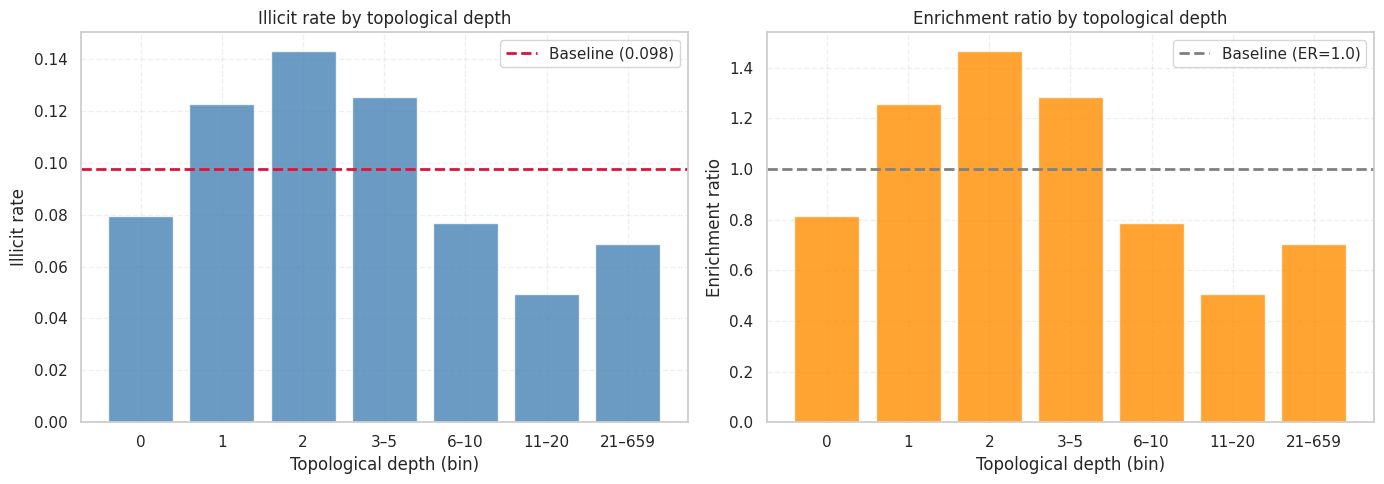

In [37]:
# =========================================================
# STEP 12B — TOPO_DEPTH ENRICHMENT ANALYSIS
# topo_depth đã compute nhưng chưa dùng trong enrichment
# =========================================================

print("=== Topo-depth enrichment: do deeper nodes have higher illicit rate? ===\n")

labeled_ps1 = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline    = (labeled_ps1["class_label"] == "illicit").mean()

# Chia topo_depth thành các bins
max_depth = labeled_ps1["topo_depth"].max()
bins = [0, 1, 2, 3, 5, 10, 20, max_depth + 1]
labels_bins = ["0", "1", "2", "3–5", "6–10", "11–20", f"21–{int(max_depth)}"]

labeled_ps1["depth_bin"] = pd.cut(
    labeled_ps1["topo_depth"],
    bins=bins,
    labels=labels_bins,
    right=False
)

topo_enrichment = (
    labeled_ps1.groupby("depth_bin", observed=True)
    .apply(lambda g: pd.Series({
        "n_labelled":   len(g),
        "n_illicit":    (g["class_label"] == "illicit").sum(),
        "illicit_rate": (g["class_label"] == "illicit").mean(),
        "enrichment":   (g["class_label"] == "illicit").mean() / baseline,
    }))
    .reset_index()
)

topo_enrichment["illicit_rate"] = topo_enrichment["illicit_rate"].round(4)
topo_enrichment["enrichment"]   = topo_enrichment["enrichment"].round(4)

display(topo_enrichment)
topo_enrichment.to_csv("ps1_topo_depth_enrichment.csv", index=False)

# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(topo_enrichment["depth_bin"].astype(str),
            topo_enrichment["illicit_rate"],
            color="steelblue", alpha=0.8)
axes[0].axhline(y=baseline, color="crimson", linestyle="--",
                linewidth=2, label=f"Baseline ({baseline:.3f})")
axes[0].set_xlabel("Topological depth (bin)")
axes[0].set_ylabel("Illicit rate")
axes[0].set_title("Illicit rate by topological depth")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.3)

axes[1].bar(topo_enrichment["depth_bin"].astype(str),
            topo_enrichment["enrichment"],
            color="darkorange", alpha=0.8)
axes[1].axhline(y=1.0, color="gray", linestyle="--", linewidth=2, label="Baseline (ER=1.0)")
axes[1].set_xlabel("Topological depth (bin)")
axes[1].set_ylabel("Enrichment ratio")
axes[1].set_title("Enrichment ratio by topological depth")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("ps1_topo_depth_enrichment_plot.png", dpi=150)
plt.show()

In [38]:
# =========================================================
# STEP 12 — EXPORT FINAL PS1 RESULTS (CẬP NHẬT)
# Thay Cell 40 cũ
# =========================================================

global_stats.to_csv("ps1_global_stats.csv")
group_stats_mean.to_csv("ps1_group_stats_mean.csv")
group_stats_median.to_csv("ps1_group_stats_median.csv")
mw_results.to_csv("ps1_mannwhitney_effects.csv", index=False)
comparison_df.to_csv("ps1_effectsize_comparison.csv", index=False)        
threshold_sensitivity_df.to_csv("ps1_threshold_sensitivity.csv", index=False)
ks_results.to_csv("ps1_ks_statistics.csv", index=False)
cov_asym.to_csv("ps1_label_coverage_asymmetry.csv", index=False)          
cov_reach.to_csv("ps1_label_coverage_reach_asymmetry.csv", index=False)   
cov_topo.to_csv("ps1_label_coverage_topo_depth.csv", index=False)         
pu_enrichment_signed_df.to_csv(
    "ps1_pu_enrichment_signed_bootstrap_permutation.csv", index=False
)
topo_enrichment.to_csv("ps1_topo_depth_enrichment.csv", index=False)      

print("✓ All PS1 result tables exported:")
print("  - ps1_global_stats.csv")
print("  - ps1_group_stats_mean/median.csv")
print("  - ps1_mannwhitney_effects.csv")
print("  - ps1_effectsize_comparison.csv          [NEW]")
print("  - ps1_threshold_sensitivity.csv")
print("  - ps1_ks_statistics.csv")
print("  - ps1_label_coverage_*.csv               [NEW x3]")
print("  - ps1_pu_enrichment_signed_bootstrap_permutation.csv")
print("  - ps1_topo_depth_enrichment.csv          [NEW]")

✓ All PS1 result tables exported:
  - ps1_global_stats.csv
  - ps1_group_stats_mean/median.csv
  - ps1_mannwhitney_effects.csv
  - ps1_effectsize_comparison.csv          [NEW]
  - ps1_threshold_sensitivity.csv
  - ps1_ks_statistics.csv
  - ps1_label_coverage_*.csv               [NEW x3]
  - ps1_pu_enrichment_signed_bootstrap_permutation.csv
  - ps1_topo_depth_enrichment.csv          [NEW]
